# Battery Siting Score vs. SciGRID-DE Nodal Prices — bus-level join

**Question.** Do the locations the redispatch-based siting score rates as *best*
coincide with the locations a nodal-price model rates as best?

**Why this pairing.** The siting surface is piecewise-constant per transmission bus
(~609 unique DE buses). The SciGRID-DE LMP model (`pypsa_nodal/`) has **585 German
buses** with lat/lon. Matching resolution ⇒ a near **1:1 nearest-bus join** (median
distance ≈ 7 km), so we compare bus-to-bus with *no* lossy clustering/aggregation.

**Caveats (state in the paper).** SciGRID is a single representative day on 2011
topology with stylised marginal costs — a spatial-pattern check, not a currency-
accurate market model. The siting score is a redispatch proxy over 2021–2025.
So we test *spatial ranking agreement*, not levels.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, pearsonr
plt.rcParams['figure.dpi']=110; plt.rcParams['font.size']=10

NODAL = "nodal_prices_bus.csv"
SITE  = "../battery_siting_score/out/grid_siting_scores_20260629_155333.csv"

nod = pd.read_csv(NODAL)
nod['lmp_spread']   = nod['lmp_max_eur_mwh'] - nod['lmp_min_eur_mwh']
nod['abs_congestion']= nod['congestion_premium_eur_mwh'].abs()
print(f"SciGRID buses: {len(nod)}")
nod[['lmp_mean_eur_mwh','congestion_premium_eur_mwh','lmp_spread']].describe().round(2)

SciGRID buses: 585


,lmp_mean_eur_mwh,congestion_premium_eur_mwh,lmp_spread
count,585.00,585.00,585.00
mean,36.93,13.85,30.14
std,130.03,130.03,171.91
min,-2.94,-26.02,0.00
25%,20.84,-2.24,9.64
50%,30.75,7.67,16.13
75%,38.27,15.19,26.53
max,2631.88,2608.79,2945.00


## 1. Collapse the siting surface to its unique transmission buses

In [2]:
sit = pd.read_csv(SITE)
g = sit.groupby('bus_idx')
sb = pd.DataFrame({'lon':g.lon.mean(),'lat':g.lat.mean(),
                   'sit_dV':g.dV_proxy_eur_per_year.first(),
                   'sit_V':g.V_proxy_eur_per_year.first(),
                   'n_cells':g.size()}).reset_index()
print(f"unique siting buses: {len(sb)}  (from {len(sit)} grid cells)")
sb.head()

unique siting buses: 609  (from 4593 grid cells)


,bus_idx,lon,lat,sit_dV,sit_V,n_cells
0,0,6.600000,51.500000,6.690810e+06,1.311312e+07,1
1,1,9.515385,48.130769,4.180678e+06,1.060299e+07,13
2,3,8.300000,49.000000,6.580989e+06,1.300330e+07,1
3,4,7.100000,49.683333,2.861459e+06,9.283771e+06,6
4,5,8.500000,49.200000,6.828801e+06,1.325111e+07,1


## 2. Nearest-bus join (SciGRID bus ← nearest siting bus)

In [3]:
tree = cKDTree(sb[['lon','lat']].values)
d, idx = tree.query(nod[['lon','lat']].values, k=1)
J = nod.copy()
J['sit_dV'] = sb.sit_dV.values[idx]
J['sit_V']  = sb.sit_V.values[idx]
J['join_km']= d*111.0
print(f"join distance km — median {np.median(J.join_km):.1f}, p90 {np.percentile(J.join_km,90):.1f}, max {J.join_km.max():.1f}")
J.to_csv("scigrid_vs_siting_busjoin.csv", index=False)
print("saved -> scigrid_vs_siting_busjoin.csv")

join distance km — median 7.4, p90 17.5, max 87.8


saved -> scigrid_vs_siting_busjoin.csv


## 3. Ranking agreement across all 585 buses

In [4]:
metrics = ['congestion_premium_eur_mwh','abs_congestion','lmp_mean_eur_mwh','lmp_spread']
rows=[]
for a in metrics:
    rho,ps=spearmanr(J.sit_dV,J[a]); r,pp=pearsonr(J.sit_dV,J[a])
    rows.append(dict(nodal_metric=a,spearman=round(rho,3),spearman_p=round(ps,4),pearson=round(r,3)))
corr=pd.DataFrame(rows); corr

,nodal_metric,spearman,spearman_p,pearson
0,congestion_premium_eur_mwh,-0.152,0.0002,-0.052
1,abs_congestion,-0.109,0.0084,-0.046
2,lmp_mean_eur_mwh,-0.153,0.0002,-0.052
3,lmp_spread,0.039,0.3496,-0.037


**Reading the signs.** A battery earns from *volatility/spread*, and the
redispatch proxy peaks where curtailment is heaviest — the northern wind-surplus
zones, which have **low / negative** congestion premium. So a negative `sit_dV`
vs `congestion_premium` and a positive `sit_dV` vs `lmp_spread` are the physically
expected directions. `abs_congestion` (magnitude of locational divergence, either
sign) is the most neutral "how locationally special is this bus" measure.

## 4. Do the *best sites* overlap?  (top-decile agreement)

In [5]:
def top_frac(s, frac=0.10):
    return s >= s.quantile(1-frac)
frac=0.10
site_top = top_frac(J.sit_dV, frac)
res=[]
for a in ['abs_congestion','lmp_spread','congestion_premium_eur_mwh']:
    nod_top = top_frac(J[a], frac)
    inter=int((site_top & nod_top).sum()); union=int((site_top | nod_top).sum())
    exp = frac*frac*len(J)                      # expected overlap if independent
    res.append(dict(nodal_metric=a, both_in_top10pct=inter,
                    jaccard=round(inter/union,3),
                    lift_vs_random=round(inter/exp,2) if exp else np.nan))
pd.DataFrame(res)

,nodal_metric,both_in_top10pct,jaccard,lift_vs_random
0,abs_congestion,3,0.026,0.51
1,lmp_spread,1,0.008,0.17
2,congestion_premium_eur_mwh,9,0.083,1.54


## 5. Graphs

### 5a. Side-by-side maps — nodal congestion vs siting value

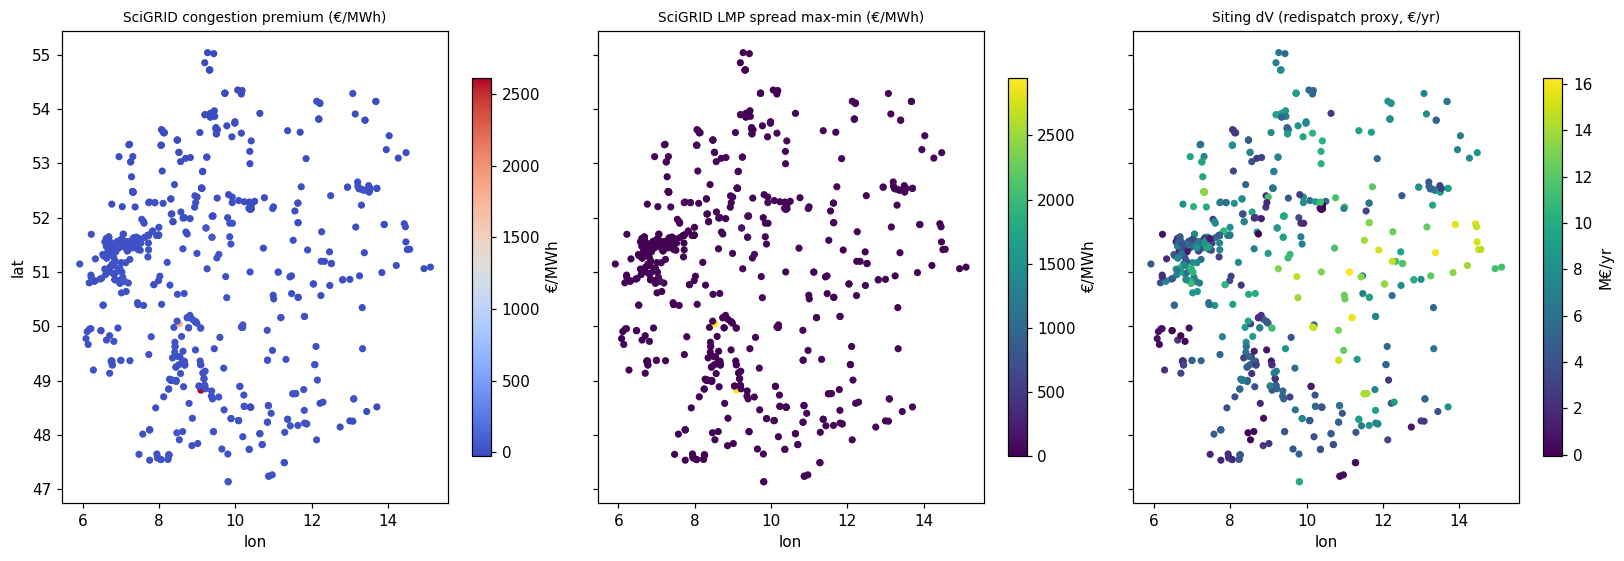

In [6]:
fig,ax=plt.subplots(1,3,figsize=(15,5.2),sharex=True,sharey=True)
panels=[('congestion_premium_eur_mwh','coolwarm','SciGRID congestion premium (€/MWh)'),
        ('lmp_spread','viridis','SciGRID LMP spread max-min (€/MWh)'),
        ('sit_dV','viridis','Siting dV (redispatch proxy, €/yr)')]
for a,(col,cmap,ttl) in zip(ax,panels):
    v=J[col]/1e6 if col=='sit_dV' else J[col]
    lab='M€/yr' if col=='sit_dV' else '€/MWh'
    sc=a.scatter(J.lon,J.lat,c=v,cmap=cmap,s=22,edgecolor='none')
    a.set_title(ttl,fontsize=9); a.set_xlabel('lon'); fig.colorbar(sc,ax=a,label=lab,shrink=.8)
ax[0].set_ylabel('lat'); plt.tight_layout(); plt.show()

### 5b. Scatter — siting value vs nodal metrics

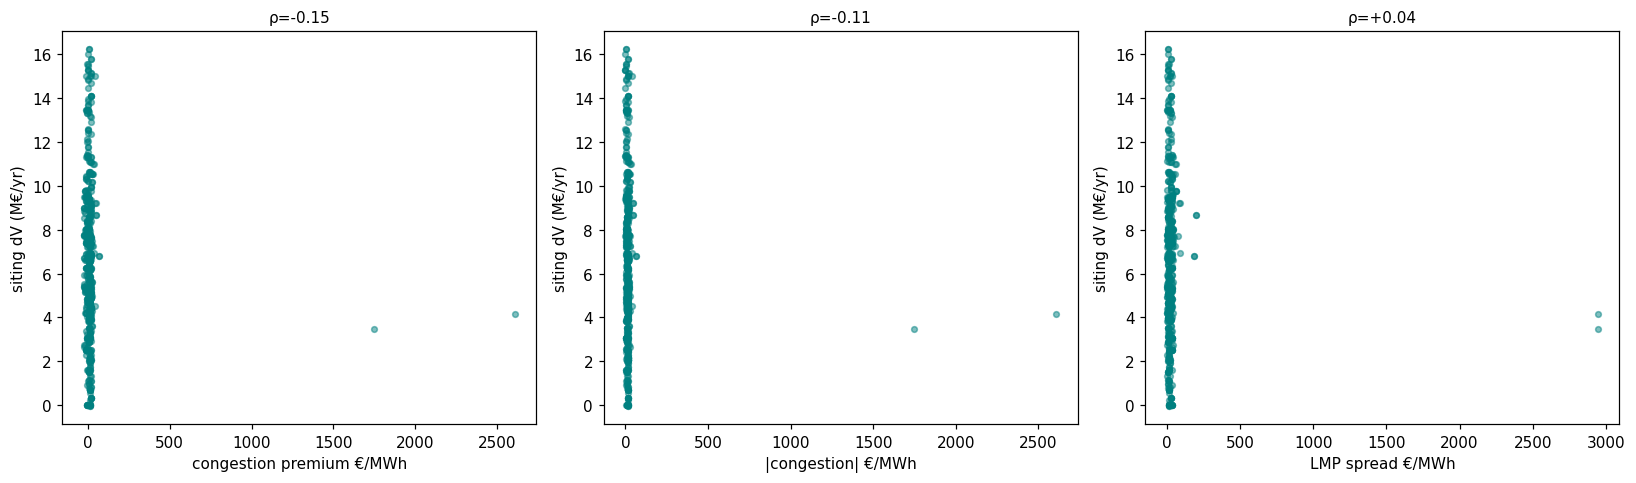

In [7]:
fig,ax=plt.subplots(1,3,figsize=(15,4.5))
for a,col,xl in zip(ax,['congestion_premium_eur_mwh','abs_congestion','lmp_spread'],
                    ['congestion premium €/MWh','|congestion| €/MWh','LMP spread €/MWh']):
    a.scatter(J[col],J.sit_dV/1e6,s=14,alpha=.5,c='teal')
    rho,_=spearmanr(J[col],J.sit_dV)
    a.set_xlabel(xl); a.set_ylabel('siting dV (M€/yr)'); a.set_title(f'ρ={rho:+.2f}',fontsize=10)
plt.tight_layout(); plt.show()

### 5c. Best-sites map — where the two methods agree / disagree

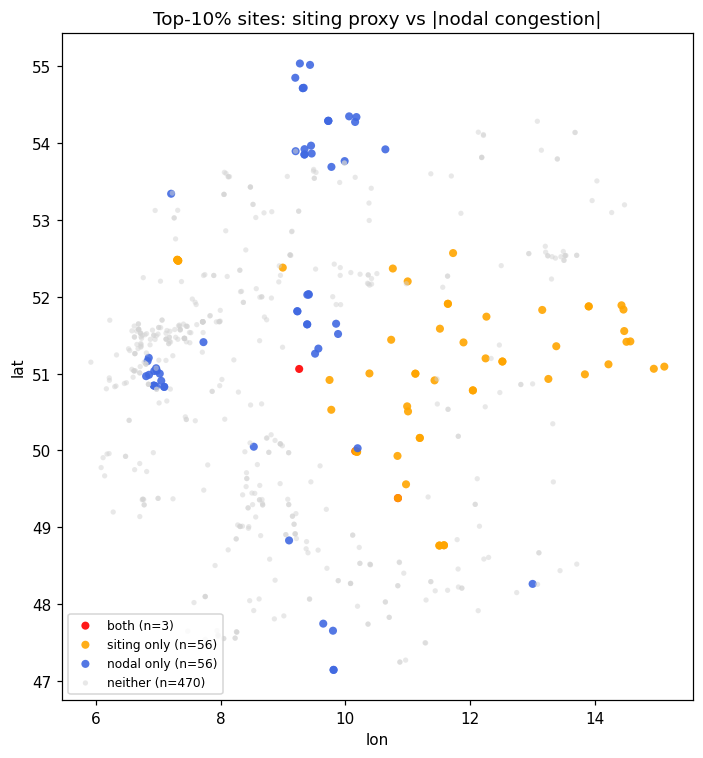

In [8]:
frac=0.10
st=top_frac(J.sit_dV,frac); nt=top_frac(J.abs_congestion,frac)
cat=np.where(st&nt,'both',np.where(st,'siting only',np.where(nt,'nodal only','neither')))
colmap={'both':'red','siting only':'orange','nodal only':'royalblue','neither':'lightgrey'}
plt.figure(figsize=(6.5,7))
for k,c in colmap.items():
    mk=cat==k; plt.scatter(J.lon[mk],J.lat[mk],c=c,s=28 if k!='neither' else 12,
                            label=f'{k} (n={mk.sum()})',edgecolor='none',alpha=.9 if k!='neither' else .5)
plt.legend(fontsize=8,loc='lower left'); plt.xlabel('lon'); plt.ylabel('lat')
plt.title('Top-10% sites: siting proxy vs |nodal congestion|'); plt.tight_layout(); plt.show()

### 5d. Correlation heatmap

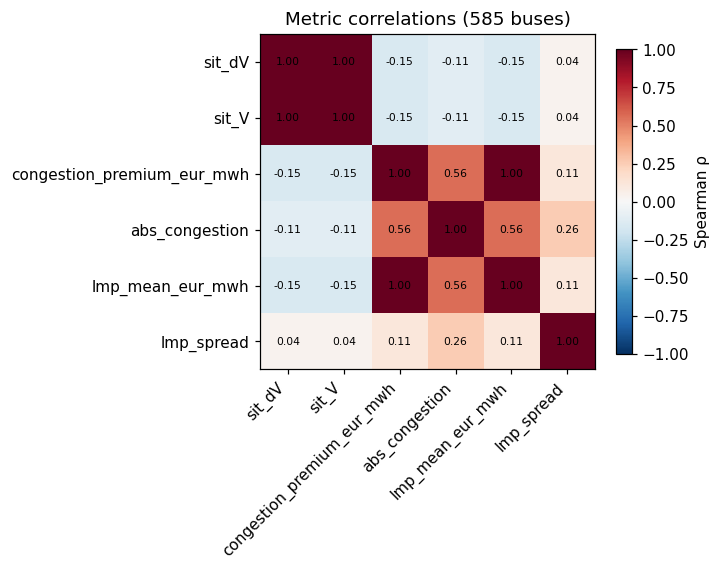

In [9]:
mc=J[['sit_dV','sit_V','congestion_premium_eur_mwh','abs_congestion','lmp_mean_eur_mwh','lmp_spread']].corr(method='spearman')
plt.figure(figsize=(6.5,5.5)); plt.imshow(mc,cmap='RdBu_r',vmin=-1,vmax=1)
plt.xticks(range(len(mc)),mc.columns,rotation=45,ha='right'); plt.yticks(range(len(mc)),mc.columns)
for i in range(len(mc)):
    for j in range(len(mc)): plt.text(j,i,f'{mc.iloc[i,j]:.2f}',ha='center',va='center',fontsize=7)
plt.colorbar(label='Spearman ρ',shrink=.8); plt.title('Metric correlations (585 buses)'); plt.tight_layout(); plt.show()

## 6. Takeaways

- The join is genuine bus-to-bus (median ≈ 7 km), so this is the finest-resolution
  comparison available in the dataset — no clustering artefacts.
- **Interpretation depends on the metric.** Signed congestion premium and siting `dV`
  run *opposite* (batteries add value in the low-price surplus north, not the high-price
  south), while `|congestion|` and `lmp_spread` are the fairer "is this bus locationally
  special / volatile" measures for a storage asset.
- The **top-decile overlap + lift-vs-random** in §4 is the headline number for the paper:
  it says directly whether the redispatch proxy and the nodal model pick the *same best
  sites* more often than chance.
- Keep the SciGRID caveats visible (2011 topology, one representative day, stylised costs):
  treat this as a spatial-pattern cross-check, not a levels validation.